<a href="https://colab.research.google.com/github/fajarekasa555/KA-Kelompok-UAS/blob/main/01_Decision_Tree_Data_Understanding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving heart.csv to heart (1).csv


In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report

In [ ]:
import pandas as pd

df = pd.read_csv('heart.csv')
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [ ]:
print("Jumlah baris dan kolom: ", df.shape)
print("Jumlah kata: ", df.shape[0])
print("Jumlah kolom: ", df.shape[1])

Jumlah baris dan kolom:  (1025, 14)
Jumlah kata:  1025
Jumlah kolom:  14


In [ ]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1025.0,54.434146,9.072290,29.0,48.0,56.0,61.0,77.0
sex,1025.0,0.695610,0.460373,0.0,0.0,1.0,1.0,1.0
cp,1025.0,0.942439,1.029641,0.0,0.0,1.0,2.0,3.0
trestbps,1025.0,131.611707,17.516718,94.0,120.0,130.0,140.0,200.0
chol,1025.0,246.000000,51.592510,126.0,211.0,240.0,275.0,564.0
fbs,1025.0,0.149268,0.356527,0.0,0.0,0.0,0.0,1.0
restecg,1025.0,0.529756,0.527878,0.0,0.0,1.0,1.0,2.0
thalach,1025.0,149.114146,23.005724,71.0,132.0,152.0,166.0,202.0
exang,1025.0,0.336585,0.472772,0.0,0.0,0.0,1.0,1.0
oldpeak,1025.0,1.071512,1.175053,0.0,0.0,0.8,1.8,6.2


In [ ]:
missing = df.isnull().sum()

missing_df = pd.DataFrame({
    'Kolom': missing.index,
    'Jumlah Missing Value': missing.values
})

missing_df

,Kolom,Jumlah Missing Value
0,age,0
1,sex,0
2,cp,0
3,trestbps,0
4,chol,0
5,fbs,0
6,restecg,0
7,thalach,0
8,exang,0
9,oldpeak,0


In [ ]:
duplicate_count = df.duplicated().sum()

print("Jumlah data duplikat: ", duplicate_count)

Jumlah data duplikat:  723


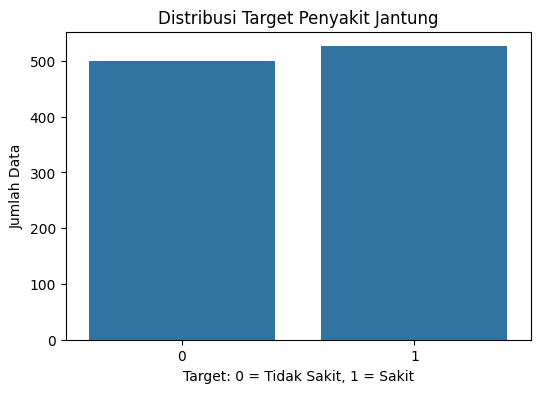

In [ ]:
df['target'].value_counts()

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='target')
plt.title('Distribusi Target Penyakit Jantung')
plt.xlabel('Target: 0 = Tidak Sakit, 1 = Sakit')
plt.ylabel('Jumlah Data')
plt.show()

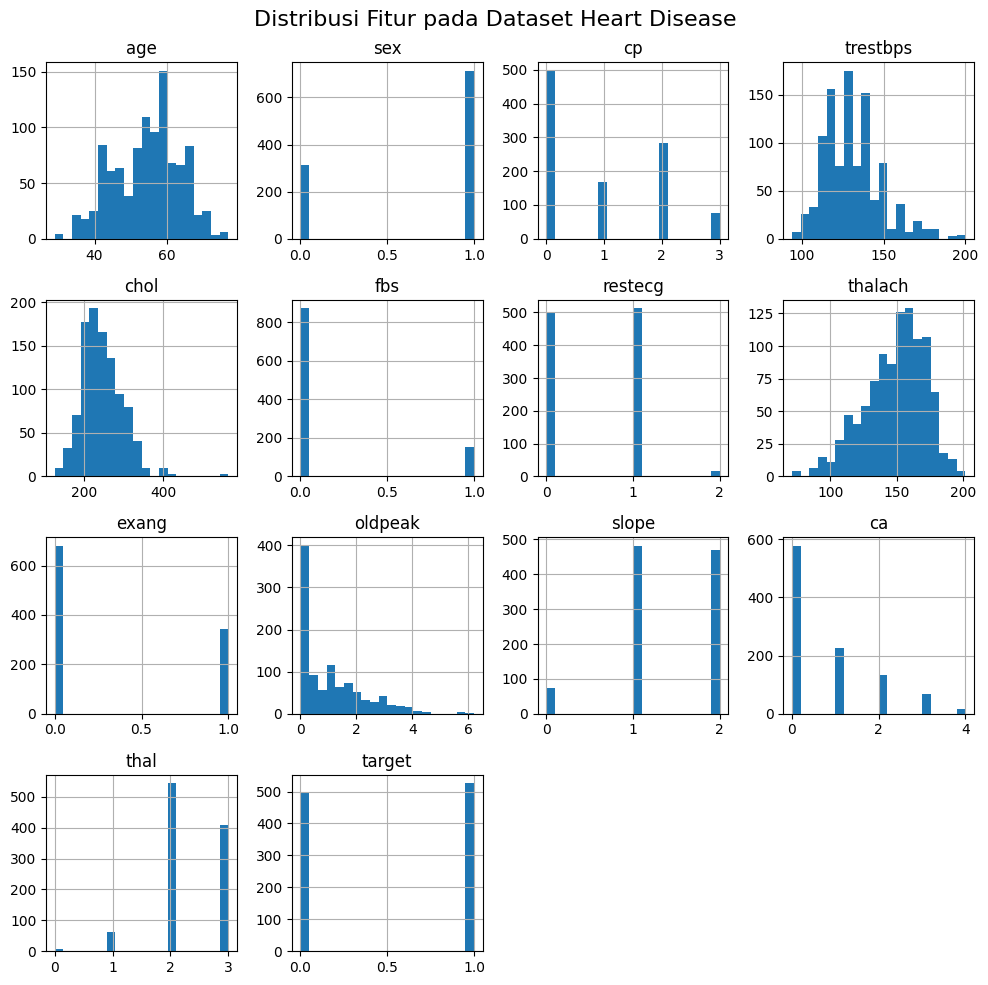

In [ ]:
df.hist(figsize=(10, 10), bins=20)
plt.suptitle('Distribusi Fitur pada Dataset Heart Disease', fontsize=16)
plt.tight_layout()
plt.show()

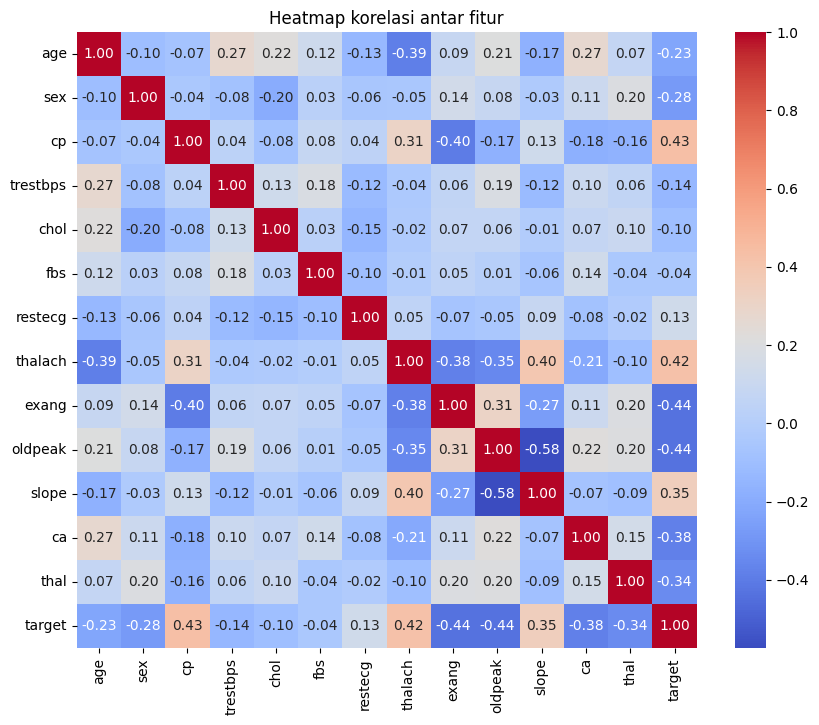

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Heatmap korelasi antar fitur')
plt.show()

In [ ]:
target_corr = df.corr()['target'].sort_values(ascending=False)
target_corr

,target
target,1.000000
cp,0.434854
thalach,0.422895
slope,0.345512
restecg,0.134468
fbs,-0.041164
chol,-0.099966
trestbps,-0.138772
age,-0.229324
sex,-0.279501


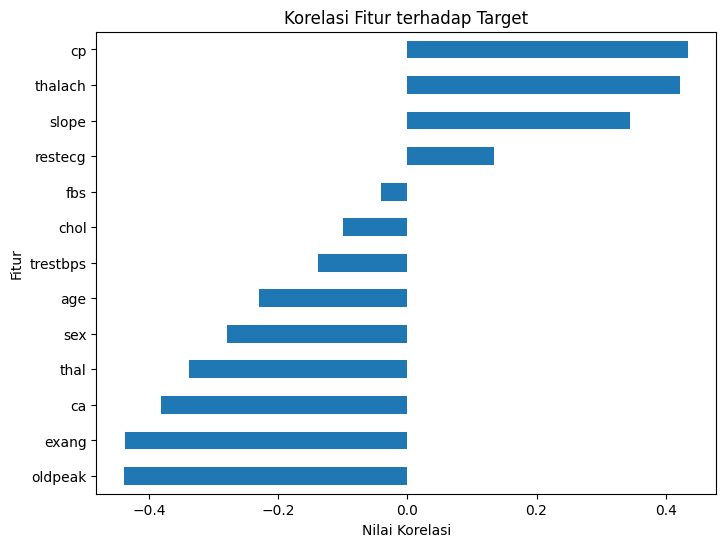

In [ ]:
plt.figure(figsize=(8,6))
target_corr.drop('target').sort_values().plot(kind='barh')
plt.title('Korelasi Fitur terhadap Target')
plt.xlabel('Nilai Korelasi')
plt.ylabel('Fitur')
plt.show()

In [ ]:
X = df.drop('target', axis=1)
y = df['target']

print("Ukuran X:", X.shape)
print("Ukuran y:", y.shape)

Ukuran X: (1025, 13)
Ukuran y: (1025,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Jumlah data training:", X_train.shape[0])
print("Jumlah data testing:", X_test.shape[0])

Jumlah data training: 820
Jumlah data testing: 205


In [ ]:
dt_model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=4,
    random_state=42
)

dt_model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=4, random_state=42)

In [ ]:
y_pred_dt = dt_model.predict(X_test)

y_pred_dt

array([0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0,
       0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1,
       0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0,
       1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1,
       0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1,
       1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0,
       1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0,
       0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1,
       0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1,
       0, 1, 1, 0, 0, 1, 1])

In [ ]:
accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)

print("Evaluasi Model Decision Tree")
print("Accuracy :", accuracy_dt)
print("Precision:", precision_dt)
print("Recall   :", recall_dt)
print("F1-Score :", f1_dt)

Evaluasi Model Decision Tree
Accuracy : 0.8390243902439024
Precision: 0.8214285714285714
Recall   : 0.8761904761904762
F1-Score : 0.847926267281106


In [ ]:
eval_dt = pd.DataFrame({
    'Model': ['Decision Tree'],
    'Accuracy': [accuracy_dt],
    'Precision': [precision_dt],
    'Recall': [recall_dt],
    'F1-Score': [f1_dt]
})

eval_dt

,Model,Accuracy,Precision,Recall,F1-Score
0,Decision Tree,0.839024,0.821429,0.87619,0.847926


In [ ]:
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.86      0.80      0.83       100
           1       0.82      0.88      0.85       105

    accuracy                           0.84       205
   macro avg       0.84      0.84      0.84       205
weighted avg       0.84      0.84      0.84       205



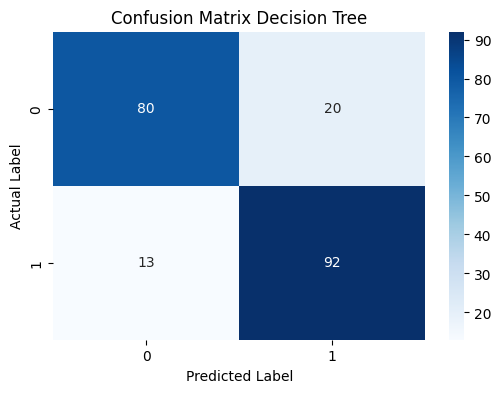

In [ ]:
cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6,4))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix Decision Tree')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

[Text(0.5267857142857143, 0.9, 'cp <= 0.5\ngini = 0.5\nsamples = 820\nvalue = [399, 421]\nclass = Sakit'),
 Text(0.2857142857142857, 0.7, 'ca <= 0.5\ngini = 0.361\nsamples = 398\nvalue = [304, 94]\nclass = Tidak Sakit'),
 Text(0.40625, 0.8, 'True  '),
 Text(0.14285714285714285, 0.5, 'thal <= 2.5\ngini = 0.498\nsamples = 175\nvalue = [93.0, 82.0]\nclass = Tidak Sakit'),
 Text(0.07142857142857142, 0.3, 'exang <= 0.5\ngini = 0.406\nsamples = 99\nvalue = [28, 71]\nclass = Sakit'),
 Text(0.03571428571428571, 0.1, 'gini = 0.195\nsamples = 64\nvalue = [7, 57]\nclass = Sakit'),
 Text(0.10714285714285714, 0.1, 'gini = 0.48\nsamples = 35\nvalue = [21, 14]\nclass = Tidak Sakit'),
 Text(0.21428571428571427, 0.3, 'oldpeak <= 0.65\ngini = 0.248\nsamples = 76\nvalue = [65, 11]\nclass = Tidak Sakit'),
 Text(0.17857142857142858, 0.1, 'gini = 0.499\nsamples = 23\nvalue = [12, 11]\nclass = Tidak Sakit'),
 Text(0.25, 0.1, 'gini = 0.0\nsamples = 53\nvalue = [53, 0]\nclass = Tidak Sakit'),
 Text(0.428571428

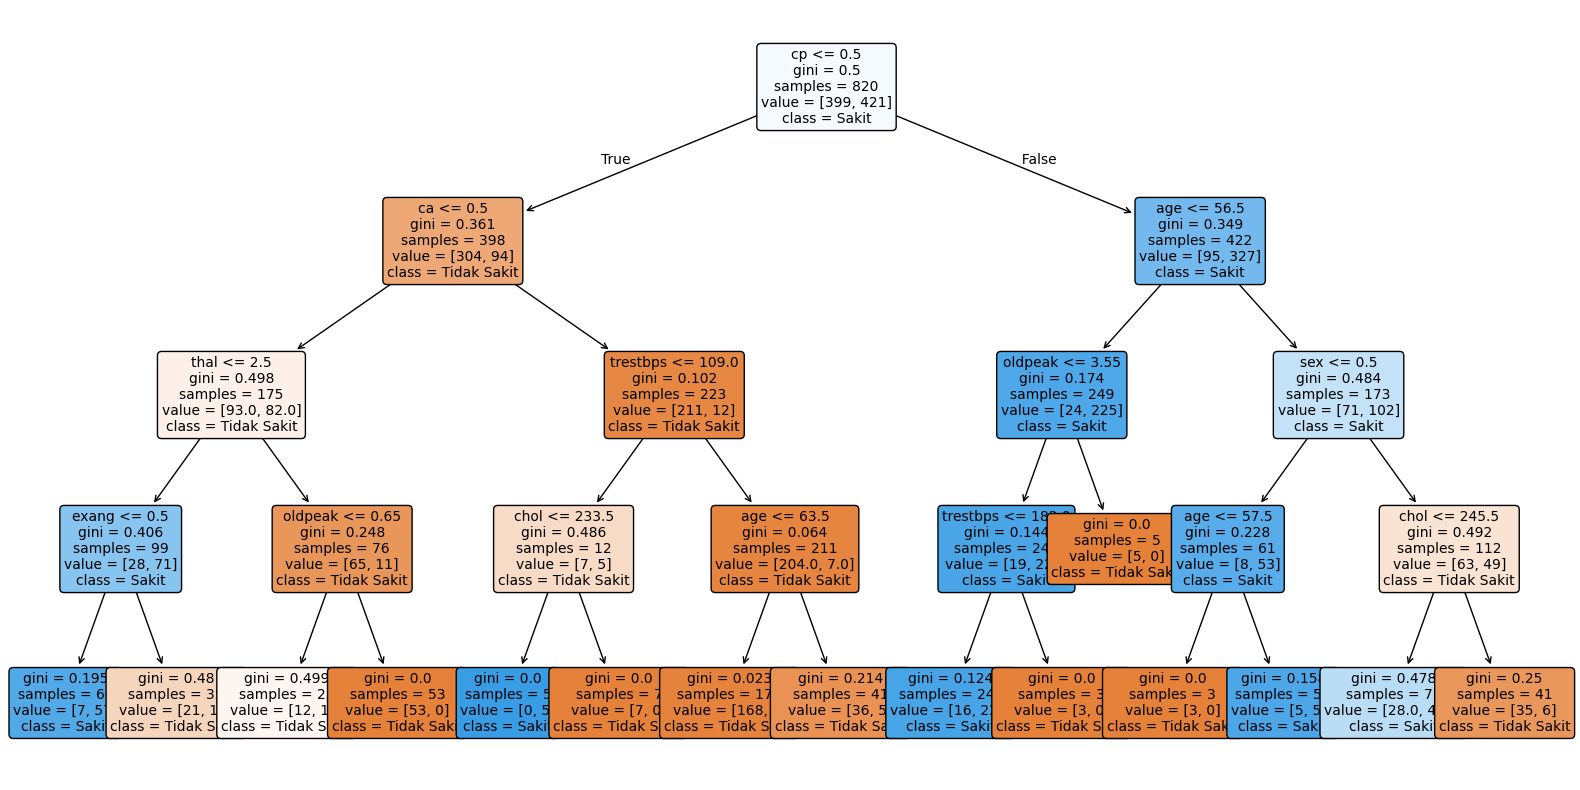

In [ ]:
plt.figure(figsize=(20, 10))
plot_tree(
    dt_model,
    feature_names=X.columns,
    class_names=['Tidak Sakit', 'Sakit'],
    filled=True,
    rounded=True,
    fontsize=10
)